In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import TwoLocal
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, amplitude_damping_error, phase_damping_error, depolarizing_error, PauliError
from qiskit.quantum_info import Statevector, Pauli, SparsePauliOp, StabilizerState, DensityMatrix
from scipy.optimize import minimize

import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from tqdm import tqdm

import matplotlib.pyplot as plt

np.random.seed(4)

num_qubits = 12
num_layers = 4

def create_sk_hamiltonian(num_qubits):
    coefs = []
    zz_terms = []
    for i in range(num_qubits):
        for j in range(i+1, num_qubits):
            pauli_str = ['I'] * num_qubits
            pauli_str[i] = 'Z'
            pauli_str[j] = 'Z'
            
            coef = np.random.normal()/np.sqrt(num_qubits)
            
            coefs.append(coef)
            zz_terms.append(SparsePauliOp(''.join(pauli_str), coeffs=coef))
            
    
    # X terms (transverse field)
    x_terms = []
    for i in range(num_qubits):
        pauli_str = ['I']*num_qubits
        pauli_str[i] = 'X'
        x_terms.append(SparsePauliOp(''.join(pauli_str), coeffs=1))
    
    return coefs, sum(zz_terms + x_terms)
    
coefs, hamiltonian = create_sk_hamiltonian(num_qubits)
coefs = coefs + [1]*12

ansatz = TwoLocal(
    num_qubits,
    rotation_blocks='ry',
    entanglement_blocks='cx',
    entanglement='circular',
    reps=num_layers,
    skip_final_rotation_layer=True,
    insert_barriers=True
)

initial_params = np.random.uniform(-np.pi, np.pi, ansatz.num_parameters)
backend_noiseless = AerSimulator(method='statevector')

def noiseless_cost(params):
    bound_circuit = ansatz.assign_parameters(params)
    
    transpiled = transpile(bound_circuit, backend_noiseless)
    transpiled.save_statevector()
    job = backend_noiseless.run(transpiled)
    result = job.result()
    statevector = result.get_statevector()
    
    return np.real(statevector.expectation_value(hamiltonian))

def build_noise_model(model, two_qubit_error_rate):
    noise_model = NoiseModel()
    if model == 'depolarization':
        cnot_error = depolarizing_error(two_qubit_error_rate, 2)
        noise_model.add_all_qubit_quantum_error(cnot_error, ['cx'])
            
    elif model == 'pauli':
        p_id = 1 - two_qubit_error_rate/2
        p_x = two_qubit_error_rate/6
        p_y = p_x - p_x/3
        p_z = p_x + p_x/3
        pauli_strings = ["II", "IX", "XI", "YI", "IY", "ZI", "IZ", "XX", "YY", "ZZ", "XY", "YX", "XZ", "ZX", "YZ", "ZY"]
        probas = [p_id**2, p_id*p_x, p_id*p_x, p_id*p_y, p_id*p_y, p_id*p_z, p_id*p_z, p_x**2, p_y**2, p_z**2, p_x*p_y, p_x*p_y, p_x*p_z, p_x*p_z, p_y*p_z, p_y*p_z]
        pauli_error = PauliError(pauli_strings, probas)
        noise_model.add_all_qubit_quantum_error(pauli_error, ['cx'])
            
    elif model == 'composite':
        amp_err = amplitude_damping_error(two_qubit_error_rate / 2)
        phase_err = phase_damping_error(two_qubit_error_rate / 2)
        two_qubit_amp = amp_err.tensor(amp_err)
        two_qubit_phase = phase_err.tensor(phase_err)
        dep_err = depolarizing_error(two_qubit_error_rate, 2)
        combined_error = two_qubit_amp.compose(two_qubit_phase).compose(dep_err)
        noise_model.add_all_qubit_quantum_error(combined_error, 'cx')
        
        # Use density matrix simulator for noisy simulation
    simulator = AerSimulator(method='density_matrix', noise_model=noise_model)
    return simulator

def noisy_cost(params, backend_noisy):
    noisy_circuit = transpile(ansatz.assign_parameters(params), backend_noisy)
    noisy_circuit.save_density_matrix()
    result_noisy = backend_noisy.run(noisy_circuit).result()
    density_matrix = result_noisy.data()['density_matrix']
    noisy_energy = np.real(density_matrix.expectation_value(hamiltonian))
    
    return noisy_energy

def mitigated_cost(params, backend_noisy, model):
    bound_circuit = ansatz.assign_parameters(params)
    
    noisy_circuit = transpile(bound_circuit, backend_noisy)
    noisy_circuit.save_density_matrix()
    result_noisy = backend_noisy.run(noisy_circuit).result()
    density_matrix_data = result_noisy.data(0).get('density_matrix')
    dm = DensityMatrix(density_matrix_data)
    
    expectations = [np.array([np.real(dm.expectation_value(obs)) for obs in observables])]
    
    return sum(model.predict(expectations)[0]*coefs)

observables = []
for i in range(num_qubits):
    for j in range(i+1, num_qubits):
        pauli_str = ['I'] * num_qubits
        pauli_str[i] = 'Z'
        pauli_str[j] = 'Z'
        observables.append(Pauli(''.join(pauli_str)))
        
for i in range(num_qubits):
    pauli_str = ['I'] * num_qubits
    pauli_str[i] = 'X'
    observables.append(Pauli(''.join(pauli_str)))

grid = np.arange(-np.pi, np.pi*11/10, np.pi/10)

C:\Temp\ipykernel_3468\2680487307.py:51: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(


In [2]:
result_noiseless = minimize(
    noiseless_cost,
    initial_params,
    method='L-BFGS-B',
    options={'maxiter': 50}
)

In [3]:
result_noiseless.fun

np.float64(-11.557650718169036)

In [4]:
params = result_noiseless.x

In [5]:
model = 'composite'
two_qubit_error_rate = 0.05
backend_noisy = build_noise_model(model, two_qubit_error_rate)

df_near = pd.read_csv('./data/datasets/near_composite005.csv')
df_full = pd.read_csv('./data/datasets/composite005.csv')

num_terms = num_qubits*(num_qubits+1)//2

X_near = df_near[[f'noisy_{n}' for n in range(num_terms)]].values
y_near = df_near[[f'target_{n}' for n in range(num_terms)]].values

X_full = df_full[[f'noisy_{n}' for n in range(num_terms)]].values
y_full = df_full[[f'target_{n}' for n in range(num_terms)]].values

pipe_near = Pipeline([
    ("scaler", StandardScaler()),
    ("linear", Ridge(alpha=1.0))
])
pipe_near.fit(X_near, y_near)

noisy_composite_landscape = []
mitigated_composite_landscape = []
for param1 in tqdm(grid):
    noisy_row = []
    mitigated_row = []
    for param2 in grid:
        params[25] = param1
        params[37] = param2
        noisy_row.append(noisy_cost(params, backend_noisy))
        mitigated_row.append(mitigated_cost(params, backend_noisy, pipe_near))
    noisy_composite_landscape.append(noisy_row)
    mitigated_composite_landscape.append(mitigated_row)

100%|██████████████████████████████████████████████████████████████████████████████████| 21/21 [19:11<00:00, 54.85s/it]


In [6]:
model = 'pauli'
two_qubit_error_rate = 0.05
backend_noisy = build_noise_model(model, two_qubit_error_rate)

df_near = pd.read_csv('./data/datasets/near_pauli005.csv')
df_full = pd.read_csv('./data/datasets/pauli005.csv')

X_near = df_near[[f'noisy_{n}' for n in range(num_terms)]].values
y_near = df_near[[f'target_{n}' for n in range(num_terms)]].values

X_full = df_full[[f'noisy_{n}' for n in range(num_terms)]].values
y_full = df_full[[f'target_{n}' for n in range(num_terms)]].values

pipe_near = Pipeline([
    ("scaler", StandardScaler()),
    ("linear", Ridge(alpha=1.0))
])
pipe_near.fit(X_near, y_near)

noisy_pauli_landscape = []
mitigated_pauli_landscape = []
for param1 in tqdm(grid):
    noisy_row = []
    mitigated_row = []
    for param2 in grid:
        params[25] = param1
        params[37] = param2
        noisy_row.append(noisy_cost(params, backend_noisy))
        mitigated_row.append(mitigated_cost(params, backend_noisy, pipe_near))
    noisy_pauli_landscape.append(noisy_row)
    mitigated_pauli_landscape.append(mitigated_row)

100%|██████████████████████████████████████████████████████████████████████████████████| 21/21 [18:22<00:00, 52.49s/it]


In [7]:
ideal_landscape = []
for param1 in tqdm(grid):
    row = []
    for param2 in grid:
        params[25] = param1
        params[37] = param2
        row.append(noiseless_cost(params))
    ideal_landscape.append(row)

100%|██████████████████████████████████████████████████████████████████████████████████| 21/21 [00:28<00:00,  1.36s/it]


In [8]:
noisy_pauli_landscape = np.array(noisy_pauli_landscape)
mitigated_pauli_landscape = np.array(mitigated_pauli_landscape)

noisy_composite_landscape = np.array(noisy_composite_landscape)
mitigated_composite_landscape = np.array(mitigated_composite_landscape)
ideal_landscape = np.array(ideal_landscape)

In [9]:
vmin = min(noisy_pauli_landscape.min(), mitigated_pauli_landscape.min(),
           noisy_composite_landscape.min(), mitigated_composite_landscape.min(), ideal_landscape.min())
vmax = max(noisy_pauli_landscape.max(), mitigated_pauli_landscape.max(),
           noisy_composite_landscape.max(), mitigated_composite_landscape.max(), ideal_landscape.max())

In [10]:
x = grid
extent = [x[0], x[-1], x[0], x[-1]] 

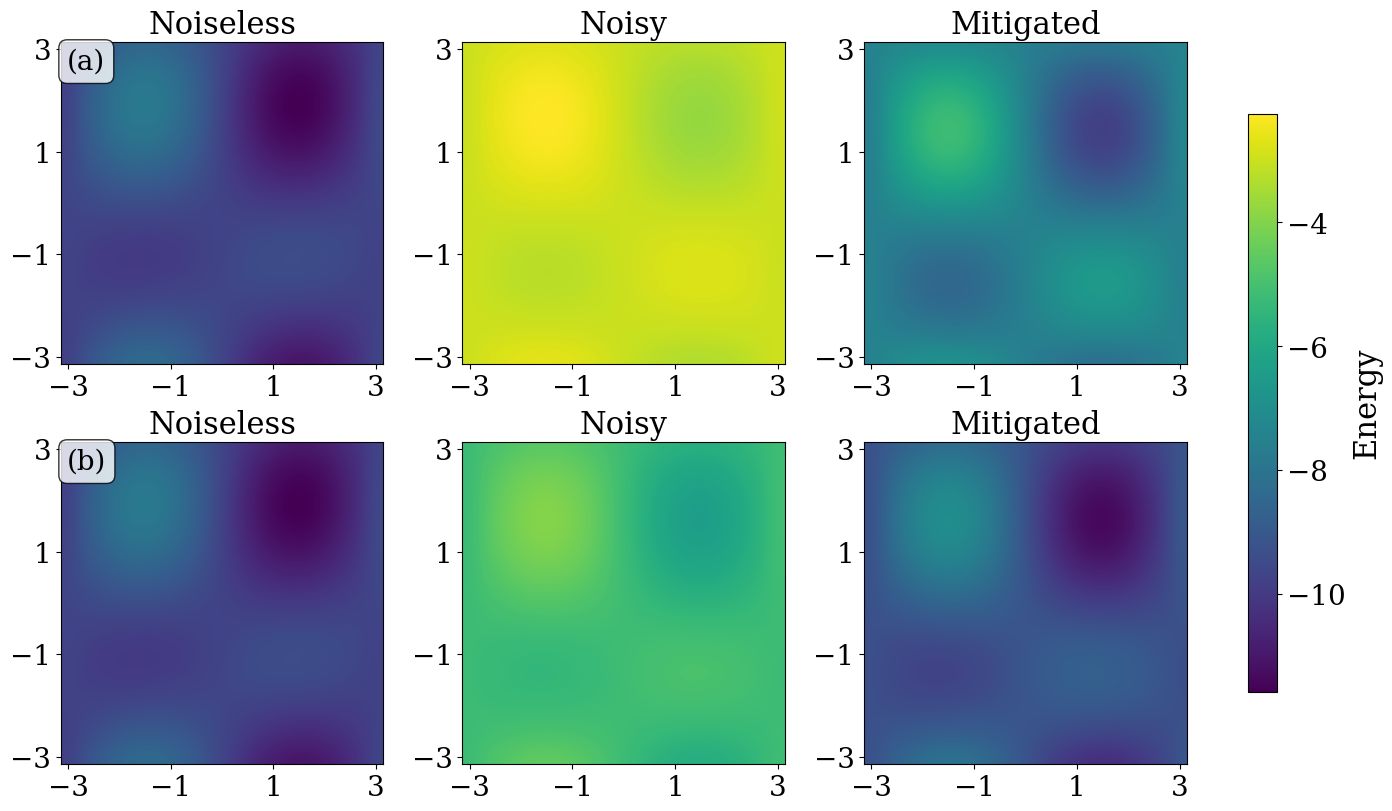

In [11]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.family": "serif",               # use serif font (like LaTeX)
    "mathtext.fontset": "cm",              # Computer Modern for math
    "axes.labelsize": 22,
    "axes.titlesize": 22,
    "legend.fontsize": 20,
    "xtick.labelsize": 20,          # X tick labels
    "ytick.labelsize": 20,
    "text.usetex": False                   # do not use external LaTeX
})

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']   # or any available serif font

# Create figure with constrained_layout
fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

# Row 0: AD data
im00 = axes[0,0].imshow(ideal_landscape, extent=extent, origin='lower',
                         vmin=vmin, vmax=vmax, cmap='viridis', interpolation='spline36')
axes[0,1].imshow(noisy_composite_landscape, extent=extent, origin='lower',
                 vmin=vmin, vmax=vmax, cmap='viridis', interpolation='spline36')
axes[0,2].imshow(mitigated_composite_landscape, extent=extent, origin='lower',
                 vmin=vmin, vmax=vmax, cmap='viridis', interpolation='spline36')

# Row 1: Pauli data
axes[1,0].imshow(ideal_landscape, extent=extent, origin='lower',
                 vmin=vmin, vmax=vmax, cmap='viridis', interpolation='spline36')
axes[1,1].imshow(noisy_pauli_landscape, extent=extent, origin='lower',
                 vmin=vmin, vmax=vmax, cmap='viridis', interpolation='spline36')
axes[1,2].imshow(mitigated_pauli_landscape, extent=extent, origin='lower',
                 vmin=vmin, vmax=vmax, cmap='viridis', interpolation='spline36')

# Integer ticks for all subplots
for ax in axes.flat:
    ymin, ymax = ax.get_ylim()
    ticks = np.arange(np.ceil(ymin), np.floor(ymax) + 1, 2)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

# Titles
axes[0,0].set_title('Noiseless')
axes[0,1].set_title('Noisy')
axes[0,2].set_title('Mitigated')
axes[1,0].set_title('Noiseless')
axes[1,1].set_title('Noisy')
axes[1,2].set_title('Mitigated')
axes[0,0].text(0.02, 0.98, '(a)', transform=axes[0,0].transAxes, fontsize=20,
            verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3",
                                               facecolor="white", alpha=0.8))
axes[1,0].text(0.02, 0.98, '(b)', transform=axes[1,0].transAxes,fontsize=20,
            verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3",
                                               facecolor="white", alpha=0.8))

# Shared colorbar
cbar = fig.colorbar(im00, ax=axes.ravel().tolist(), label='Energy', shrink=0.8)